# Task 2 - Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

df = pd.read_csv("../data/raw/data.csv")
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


## 1. Dataset Overview

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (95662, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  object 
 1   BatchId               95662 non-null  object 
 2   AccountId             95662 non-null  object 
 3   SubscriptionId        95662 non-null  object 
 4   CustomerId            95662 non-null  object 
 5   CurrencyCode          95662 non-null  object 
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  object 
 8   ProductId             95662 non-null  object 
 9   ProductCategory       95662 non-null  object 
 10  ChannelId             95662 non-null  object 
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  object 
 14  PricingStrategy       95662 non-null  int64  
 15  

## 2. Missing Values

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing)

if not missing.empty:
    missing.sort_values().plot(kind="barh", figsize=(8,4))
    plt.title("Missing Values")
    plt.show()

Series([], dtype: int64)


## 3. Summary Statistics

In [4]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


## 4. Numerical Features

In [5]:
print(df["Amount"].describe())
print("\n")
print(df["Value"].describe())

count    9.566200e+04
mean     6.717846e+03
std      1.233068e+05
min     -1.000000e+06
25%     -5.000000e+01
50%      1.000000e+03
75%      2.800000e+03
max      9.880000e+06
Name: Amount, dtype: float64


count    9.566200e+04
mean     9.900584e+03
std      1.231221e+05
min      2.000000e+00
25%      2.750000e+02
50%      1.000000e+03
75%      5.000000e+03
max      9.880000e+06
Name: Value, dtype: float64


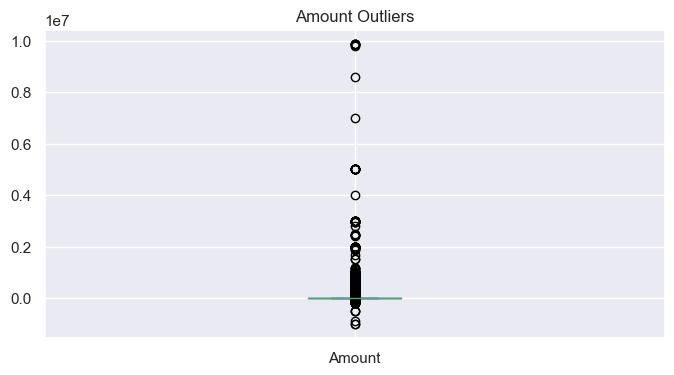

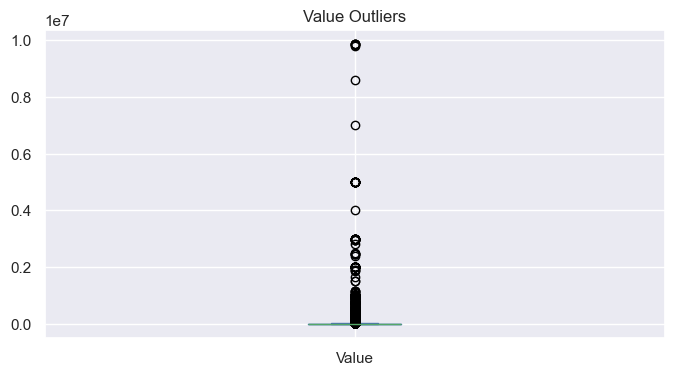

In [6]:
plt.figure(figsize=(8,4))
df["Amount"].plot.box()
plt.title("Amount Outliers")
plt.show()

plt.figure(figsize=(8,4))
df["Value"].plot.box()
plt.title("Value Outliers")
plt.show()

## 5. Categorical Features

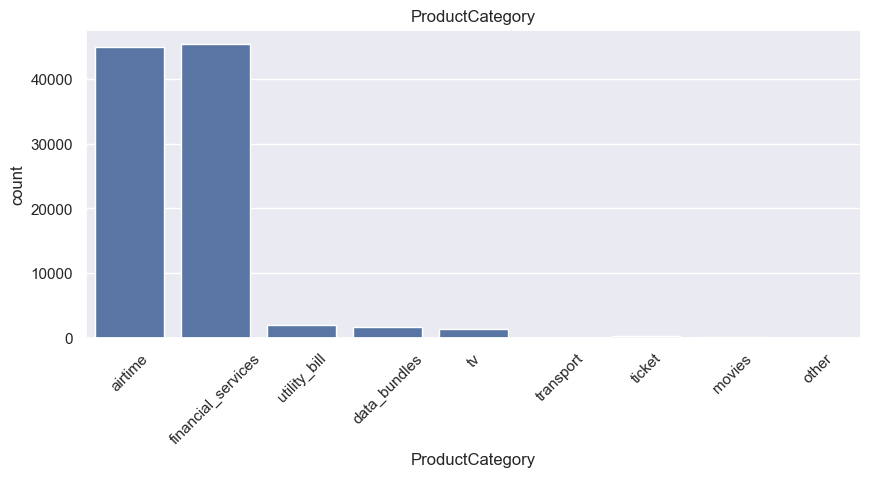

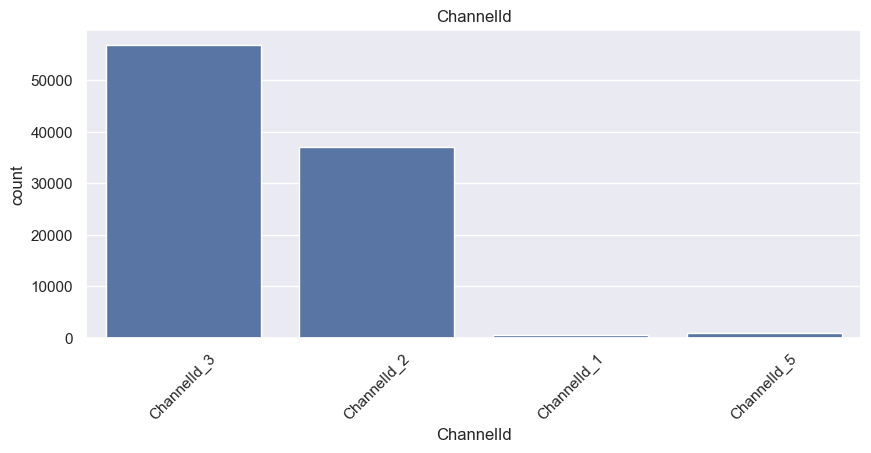

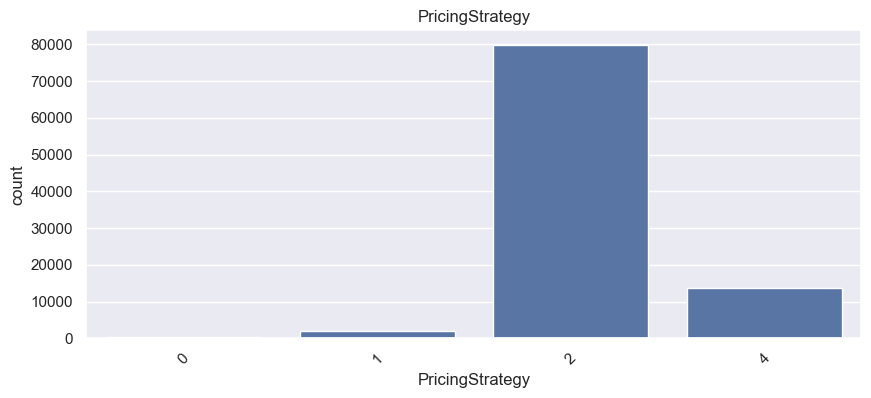

In [7]:
for col in ["ProductCategory","ChannelId","PricingStrategy"]:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

## 6. Fraud Analysis

In [8]:
print(df["FraudResult"].value_counts())
print()
print(df["FraudResult"].value_counts(normalize=True)*100)

FraudResult
0    95469
1      193
Name: count, dtype: int64

FraudResult
0    99.798248
1     0.201752
Name: proportion, dtype: float64


## 7. Time Features

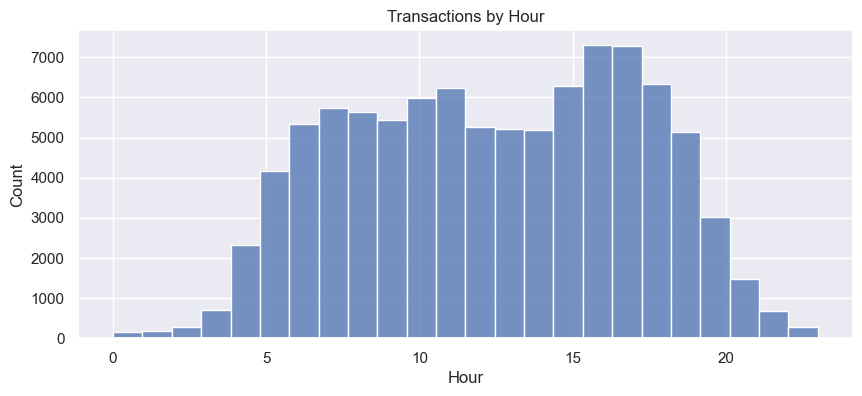

In [9]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

df["Hour"] = df["TransactionStartTime"].dt.hour

plt.figure(figsize=(10,4))
sns.histplot(df["Hour"], bins=24)
plt.title("Transactions by Hour")
plt.show()

## 8. Correlation Analysis

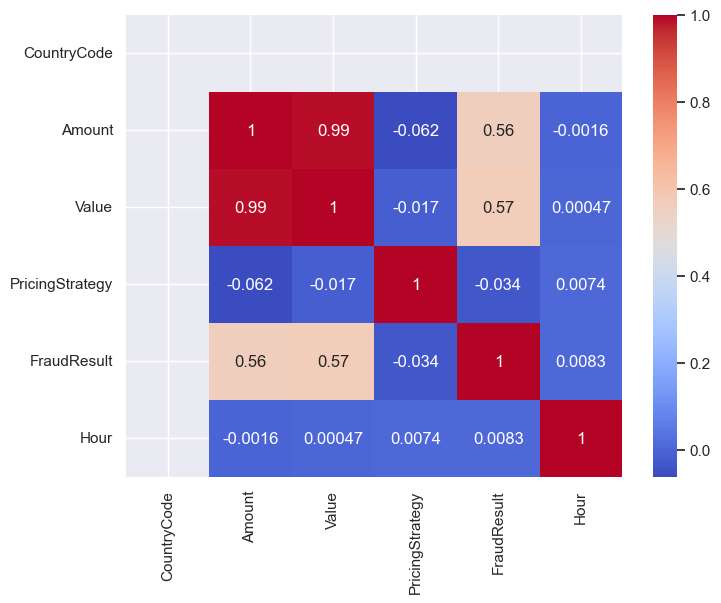

In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Final Insights (Update after running)

1. The dataset contains 95,662 transactions and multiple customer, product, and transaction attributes.
2. Amount and Value are heavily right-skewed with extreme outliers, indicating large variability in transaction behavior.
3. Amount contains negative values, suggesting refunds, reversals, or credits.
4. Transaction behavior varies across product categories and channels.
5. Fraud distribution should be checked for class imbalance before model development.
